# Taller 4 — Minería de Datos

## Jorge Andrés Sánchez Duarte
## Sistema de búsqueda y recuperación de artículos científicos


**Revista indexada:** *The Journal of Finance*

**Aplicación:** dashboard en Streamlit del Taller 2, ampliado con un módulo de búsqueda.


Este documento reproduce el proceso completo: desde los textos almacenados en SQLite hasta
las representaciones vectoriales, la representación reducida y los rankings que usa la aplicación.

Toda la lógica vive en el módulo `buscador.py`, que la app importa tal cual.


### Estrategias implementadas

| | Estrategia | Tipo | Espacio |
|---|---|---|---|
| **A** | TF-IDF + similitud coseno | léxica | disperso, alta dimensión |
| **B** | LSA (Truncated SVD sobre TF-IDF) + similitud coseno | semántica latente | **denso, reducido** |
| **C** | BM25 Okapi | léxica, probabilística | índice de tokens |

La estrategia **B** es la que cumple el requisito de construir un ranking sobre una
representación reducida.

In [ ]:
import os, sys, time, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.getcwd())
import buscador as bus

pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})

print("scikit-learn, rank_bm25 y nltk cargados desde buscador.py")
print("Base de datos:", os.path.basename(bus.DB_PATH))

scikit-learn, rank_bm25 y nltk cargados desde buscador.py
Base de datos: sqlite_webscraping.db



# 1. Construcción del corpus



In [ ]:
diag = bus.diagnostico_corpus()
diag

,campo,n_nulos_sql,n_vacios,n_disponibles,long_media_palabras
0,title,0,0,117,7.3
1,abstract,0,0,117,99.0
2,topic_label,0,0,117,2.3
3,doi,0,0,117,1.0
4,authors_raw,0,0,117,6.2
5,keywords,117,117,0,0.0


### Campos utilizados para representar cada artículo

Cada documento del índice se arma concatenando:

- **title**: Repetido **3 veces** (PESO_TITULO = 3),
- **abstract**: El resumen completo,
- **topic_label**: La categoría temática asignada en el Taller 2.

**Por qué se repite el título.** Un título tiene ~10 palabras y un resumen ~100. Si se concatenan
sin ponderar, el título aporta apenas un 9% de los términos del documento y su señal queda diluida,
aunque sea el campo que mejor describe de qué trata el artículo. Repetirlo tres veces es la forma
más simple de ponderar campos dentro de un esquema de bolsa de palabras: multiplica por 3 su
frecuencia de término (tf) sin tocar el idf ni requerir un índice por campos.

**Por qué se incluye topic_label.** Agrega entre 2 y 4 términos temáticos por documento
(*trading*, *mercados*, *riesgo*, *seguros*) que funcionan como etiquetas de dominio y ayudan en
consultas generales. El enunciado permite explícitamente incorporar campos adicionales.

**Palabras clave: No están disponibles.** La API de Crossref no expone el campo subject para
esta revista, y el sitio de Wiley bloquea el scraping automatizado (Cloudflare) . El mismo
inconveniente documentado en el Taller 2. Por eso la tabla anterior reporta 0 artículos con
palabras clave. Así que,  se documenta la
ausencia y se trabaja con título + resumen, sin inventar contenido.

In [ ]:
df = bus.cargar_corpus()

print(f"Artículos en la tabla `papers`      : {len(pd.read_sql_query('SELECT paper_id FROM papers', __import__('sqlite3').connect(bus.DB_PATH)))}")
print(f"Artículos incluidos en el índice    : {len(df)}")
print(f"Artículos excluidos (texto < 5 pal.): {117 - len(df)}")
print()
print("Longitud del texto indexado (palabras):")
print(df["texto_corpus"].str.split().str.len().describe().round(1).to_string())
print()
print("Distribución por temática:")
print(df["topic_label"].value_counts().to_string())
print()
print("Rango de fechas:", df["publication_date"].min(), "->", df["publication_date"].max())

Artículos en la tabla `papers`      : 117
Artículos incluidos en el índice    : 117
Artículos excluidos (texto < 5 pal.): 0

Longitud del texto indexado (palabras):
count    117.0
mean     123.3
std       11.8
min      100.0
25%      115.0
50%      122.0
75%      130.0
max      163.0

Distribución por temática:
topic_label
Otros                    50
Trading & Mercados       43
Riesgo & Seguros         13
IA - ML - Estadística    11

Rango de fechas: 2025-01-13 -> 2026-06-08


### Tratamiento de faltantes, idiomas y criterios de inclusión

**Valores faltantes.** En este corpus los 117 artículos tienen título y resumen no vacíos, así que
no hubo que imputar nada. El módulo aplica de todos modos fillna("") como salvaguarda: si en el
futuro se agregan artículos sin resumen desde la pestaña de scraping, el campo entra como cadena
vacía y el documento se representa solo con lo que sí tiene. **No se reemplaza ningún texto faltante
por contenido inventado**, como exige el enunciado.

**Idiomas.** El corpus es homogéneo: los 117 artículos están en inglés, porque *The Journal of Finance*
publica exclusivamente en ese idioma. Esto simplifica el preprocesamiento (una sola lista de stopwords,
un solo stemmer) y hace que el pipeline sea consistente. La consecuencia práctica es que **las consultas
también deben escribirse en inglés**: una consulta en español no comparte vocabulario con el corpus y
ninguna de las tres estrategias podría recuperar nada. Es una limitación del corpus, no del método,
y se documenta como tal.

**Criterio de inclusión.** Se indexa todo artículo cuyo texto concatenado tenga al menos 5 palabras.
Con el corpus actual esto no excluye a ninguno. El criterio existe para evitar que registros
basura (por ejemplo, avisos editoriales sin resumen ) contaminen el índice con vectores casi nulos.


# 2. Procesamiento del texto

| Operación | ¿Se aplicó? | Justificación |
|---|---|---|
| Minúsculas | **Sí** | *Bank* y *bank* son el mismo término; sin esto el vocabulario se duplica. |
| Normalización Unicode (NFKD) | **Sí** | El texto de Crossref trae guiones tipográficos (‐, U+2010), &amp; y espacios duros. Sin normalizar, Corporate M&amp;As genera tokens basura. |
| Tokenización | **Sí** | Por expresión regular [a-z]{3,}: descarta números, símbolos y tokens de 1–2 letras. |
| Eliminación de stopwords | **Sí** | Lista de scikit-learn (318 términos) **más 44 stopwords de dominio**. |
| Stemming (Snowball) | **Sí** | Une *pricing / priced / prices* → price; *investors / investment* → investor / invest. |
| Lematización | **No** | Ver justificación abajo. |
| Puntuación y números | **Eliminados** | Los años (*2016*, *2020*) y cifras aparecen en casi todos los resúmenes y no discriminan entre artículos. |
| Términos científicos | **Conservados** | No hay lista blanca: el filtro es puramente morfológico, así que *arbitrage*, *covenant* o *microstructure* sobreviven intactos. |
| Bigramas | **Sí** (en la vectorización) | Ver sección 3. |

**Por qué stemming y no lematización.** El profesor prefirio usar spaCy
(es_core_news_sm) para lematizar. Aquí se prefirió el stemmer Snowball por dos razones concretas:

1. **Despliegue.** spaCy requiere descargar un modelo de ~15 MB en tiempo de ejecución. En Streamlit
   Cloud esa descarga es frágil y consume memoria del contenedor; el SnowballStemmer de NLTK es
   código puro, sin ningún corpus que descargar.
2. **Costo/beneficio.** La lematización es lingüísticamente más confiable, pero su ventaja está en
   morfología irregular (verbos conjugados, género y número). El inglés académico es
   morfológicamente pobre: casi toda la variación son plurales y sufijos -ing / -ed, que el
   stemmer resuelve bien. La imprecisión del stemming (*policy* → polici) no importa porque **la
   consulta pasa por exactamente el mismo pipeline**: si el documento dice polici, la consulta
   también.

**Stopwords de dominio.** Además de la lista estándar se eliminan palabras que aparecen en casi
todos los resúmenes académicos (*paper*, *evidence*, *find*, *results*, *show*, *data*, *model*)
y dos que son constantes del corpus por venir todas de la misma revista: *finance* y *financial*.
Un término presente en 110 de 117 documentos tiene idf ≈ ` y solo agrega ruido. Esto complementa
el filtro max_df=0.5 de la sección 3, que hace lo mismo de forma automática.

In [ ]:
ejemplo = df.loc[df.paper_id == 64, "title"].iloc[0]
print("Título original :", ejemplo)
print("Normalizado     :", bus.normalizar(ejemplo))
print("Tokens finales  :", bus.tokenizar(ejemplo))
print()
consulta_demo = "Monetary policy transmission and bank lending"
print("Consulta        :", consulta_demo)
print("Tokens consulta :", bus.tokenizar(consulta_demo))
print()
print(f"Stopwords totales: {len(bus.STOPWORDS)} "
      f"({len(bus.STOPWORDS) - len(bus.STOPWORDS_DOMINIO)} de sklearn + {len(bus.STOPWORDS_DOMINIO)} de dominio)")

Título original : Banks, Low Interest Rates, and Monetary Policy Transmission
Normalizado     : banks low interest rates and monetary policy transmission
Tokens finales  : ['bank', 'low', 'rate', 'monetari', 'polici', 'transmiss']

Consulta        : Monetary policy transmission and bank lending
Tokens consulta : ['monetari', 'polici', 'transmiss', 'bank', 'lend']

Stopwords totales: 349 (310 de sklearn + 39 de dominio)


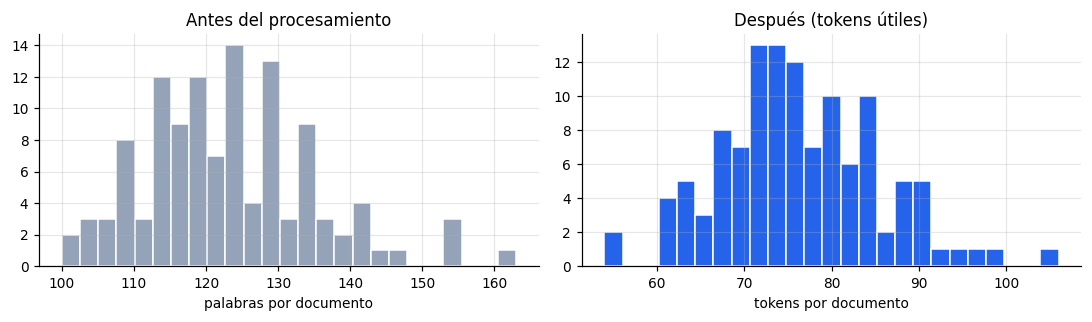

Media antes : 123.3 palabras
Media después: 76.3 tokens  (38% del texto era ruido o stopwords)


In [ ]:
corpus_tok = [bus.tokenizar(t) for t in df["texto_corpus"]]
largos = pd.Series([len(t) for t in corpus_tok])

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].hist(df["texto_corpus"].str.split().str.len(), bins=25, color="#94a3b8", edgecolor="white")
ax[0].set_title("Antes del procesamiento"); ax[0].set_xlabel("palabras por documento")
ax[1].hist(largos, bins=25, color="#2563eb", edgecolor="white")
ax[1].set_title("Después (tokens útiles)"); ax[1].set_xlabel("tokens por documento")
plt.tight_layout(); plt.show()

reduccion = 1 - largos.mean() / df["texto_corpus"].str.split().str.len().mean()
print(f"Media antes : {df['texto_corpus'].str.split().str.len().mean():.1f} palabras")
print(f"Media después: {largos.mean():.1f} tokens  ({reduccion:.0%} del texto era ruido o stopwords)")


# 3. Representación vectorial


Se usa **TF-IDF** como el paso obligado
para convertir documentos en vectores comparables por similitud coseno.

$$\text{TF-IDF}(t,d) = \text{TF}(t,d)\times \text{IDF}(t)$$

**Por qué TF-IDF y no Bag of Words simple.** BoW cuenta ocurrencias, así que una palabra frecuente
en todo el corpus (*market*, *risk*) pesa igual que una rara y distintiva (*covenant*, *microstructure*).
El id` corrige exactamente eso. Esto porque, los modelos basados en
similitud coseno prefieren TF-IDF, mientras que los conteos crudos se reservan para Naive Bayes.

**Por qué no embeddings preentrenados.** El enunciado los permite pero no los exige. Con 117
documentos, un modelo tipo *sentence-transformers* pesa ~90 MB y no cabe cómodamente en el
contenedor gratuito de Streamlit Cloud, que es donde está desplegada la app del Taller 2. La
recuperación semántica se resuelve aquí por la vía de LSA (sección 5), que se apoya en el mismo
material de clase y no depende de descargar modelos externos.

**Parámetros y su justificación:**

| Parámetro | Valor | Razón |
|---|---|---|
| `ngram_range` | `(1, 2)` | Los bigramas capturan términos compuestos que como unigramas pierden sentido: *asset pricing*, *monetary policy*, *deposit insurance*.|
| `min_df` | `2` | Descarta términos que aparecen en un solo documento: no pueden establecer similitud entre artículos y solo inflan el vocabulario. |
| `max_df` | `0.5` | Descarta términos presentes en más de la mitad del corpus: son stopwords del corpus, con idf cercano a cero. |
| `sublinear_tf` | `True` | Reemplaza tf por 1 + log(tf): la décima repetición de una palabra no vale diez veces la primera. Es la misma idea de saturación que BM25 implementa con k₁. |
| `norm` | `"l2"` | Deja los vectores con norma 1, de modo que el producto punto es directamente la similitud coseno. |

In [ ]:
t0 = time.perf_counter()
tfidf, X = bus.construir_tfidf(df["texto_corpus"].tolist())
t_fit = time.perf_counter() - t0

vocab = tfidf.get_feature_names_out()
n_uni = sum(1 for v in vocab if " " not in v)
n_bi = len(vocab) - n_uni
mem_disp = (X.data.nbytes + X.indices.nbytes + X.indptr.nbytes) / 1024
mem_dens = X.shape[0] * X.shape[1] * 8 / 1024

resumen_rep = pd.DataFrame([
    ("Documentos (n)", X.shape[0]),
    ("Dimensión / tamaño del vocabulario (p)", X.shape[1]),
    ("  · unigramas", n_uni),
    ("  · bigramas", n_bi),
    ("Entradas no nulas (nnz)", X.nnz),
    ("Densidad de la matriz", f"{X.nnz / (X.shape[0]*X.shape[1]):.2%}"),
    ("Tipo de matriz", "dispersa (scipy CSR)"),
    ("Memoria en formato disperso", f"{mem_disp:.1f} KB"),
    ("Memoria si se densificara", f"{mem_dens:.1f} KB"),
    ("Tiempo de ajuste", f"{t_fit:.2f} s"),
], columns=["Característica", "Valor"])
resumen_rep

,Característica,Valor
0,Documentos (n),117
1,Dimensión / tamaño del vocabulario (p),1128
2,· unigramas,840
3,· bigramas,288
4,Entradas no nulas (nnz),5368
5,Densidad de la matriz,4.07%
6,Tipo de matriz,dispersa (scipy CSR)
7,Memoria en formato disperso,63.4 KB
8,Memoria si se densificara,1031.1 KB
9,Tiempo de ajuste,0.11 s


In [ ]:
# Términos con mayor y menor idf: qué considera el modelo distintivo y qué genérico
idf = pd.Series(tfidf.idf_, index=vocab).sort_values()
print("Términos MENOS distintivos (idf bajo, aparecen en muchos documentos):")
print(idf.head(12).round(2).to_string())
print("\nEjemplo de bigramas retenidos:")
print([v for v in vocab if " " in v][:18])

Términos MENOS distintivos (idf bajo, aparecen en muchos documentos):
otro             1.84
increas          1.88
trade            1.90
market           1.94
trade mercado    1.99
mercado          1.99
firm             2.08
risk             2.11
rate             2.30
effect           2.34
price            2.37
cost             2.44

Ejemplo de bigramas retenidos:
['abnorm return', 'access privat', 'account level', 'achiev higher', 'acquisit cost', 'adjust return', 'advers select', 'affect bank', 'affect decis', 'affect firm', 'affin term', 'age depend', 'agent work', 'aggreg bank', 'aggreg consumpt', 'alloc decis', 'amplifi effect', 'asset alloc']


### Ventajas y limitaciones de TF-IDF

**Ventajas.** Es interpretable (cada dimensión es un término identificable), no requiere entrenar
ningún modelo, se calcula en menos de un segundo sobre este corpus y su matriz dispersa ocupa 16
veces menos memoria que su versión densa.

**Limitaciones.** No reconoce sinónimos ni relaciones semánticas: para TF-IDF, *carbon pricing* y
*ESG investing* son términos sin relación alguna, aunque describan el mismo campo. Tampoco maneja
polisemia: la palabra *algorithmic* pesa igual en *algorithmic trading* que en *algorithmic credit
decisions*, y en la sección 8 se verá que esto produce un error de recuperación concreto. Estas dos
limitaciones son precisamente lo que motiva la estrategia B.

# 4. Tipo de recuperación

El sistema implementa **recuperación léxica** (estrategias A y C) y **recuperación semántica latente**
(estrategia B). No se implementa recuperación híbrida con fusión de puntajes, por una razón que
conviene explicitar: los puntajes de las tres estrategias viven en escalas distintas,
y combinarlos exigiría una normalización adicional cuyo efecto no se podría evaluar con solo 117
documentos y 5 consultas. En su lugar, la app permite ver los rankings **lado a lado**, que es la
otra opción que el enunciado admite y que además hace visible la comparación.

### Cómo decide cada estrategia que un artículo es relevante

**A — TF-IDF + similitud coseno (léxica).**
La consulta entra a la tabla TF-IDF *como una fila más*, usando el mismo idf ya calculado sobre el
corpus. La similitud compara la **orientación** de los dos vectores, no su magnitud:

$$\cos(\theta)=\frac{\vec{q}\cdot\vec{d}}{\|\vec{q}\|\,\|\vec{d}\|}$$

Un artículo es relevante si comparte términos con la consulta, y pesa más si esos términos son raros
en el corpus. La normalización por la magnitud es lo que evita que un resumen largo gane solo por
tener más palabras.

**B — LSA + similitud coseno (semántica latente).**
La misma matriz TF-IDF se proyecta a 50 dimensiones latentes con Truncated SVD. Cada dimensión ya no
es una palabra sino una **combinación de palabras que tienden a coocurrir**. La consulta se proyecta
al mismo espacio con vd.transform(...) y se compara ahí. Un artículo es relevante si ocupa una
posición parecida en ese espacio, **aunque no comparta las palabras exactas**: LSA agrupa términos
que aparecen en contextos similares, capturando sinonimia sin ninguna regla explícita.

**C — BM25 Okapi (léxica, probabilística).**

$$\text{BM25}(D,Q)=\sum_{t\in Q}\text{IDF}(t)\cdot\frac{f(t,D)\,(k_1+1)}{f(t,D)+k_1\left(1-b+b\frac{|D|}{\overline{|D|}}\right)}$$

Parte del mismo idf de TF-IDF y agrega dos correcciones: **saturación de frecuencia** (cada
repetición adicional aporta menos) y **ajuste por longitud** (un documento largo no gana solo por
tener más palabras). Un artículo es relevante si contiene *varios* términos de la consulta y los
contiene de forma *distintiva*.


# 5. Reducción de dimensionalidad


### Método: Truncated SVD (LSA)

Se descompone la matriz documento-término $X_{n\times p}$ conservando los $k$ mayores valores
singulares:

$$X \approx X_k = U_k\,\Sigma_k\,V_k^\top$$

**Por qué Truncated SVD y no PCA.** PCA exige centrar la matriz restando la media de cada columna.
Sobre una matriz dispersa al 96%, centrar destruye la dispersión: las ~5.400 entradas no nulas se
convertirían en 131.976, y la matriz habría que mantenerla densa. Truncated SVD opera **directamente
sobre el formato disperso**, sin densificar.

**Por qué no NMF.** NMF también funciona sobre matrices no negativas y produce componentes más
interpretables como "temas". Se descartó porque sus componentes no son ortogonales ni están
ordenados por varianza explicada, lo que deja sin un criterio claro para escoger $k$; y porque su
ajuste es iterativo y bastante más lento. NMF es preferible cuando el objetivo es *interpretar* los
temas; aquí el objetivo es *rankear*.

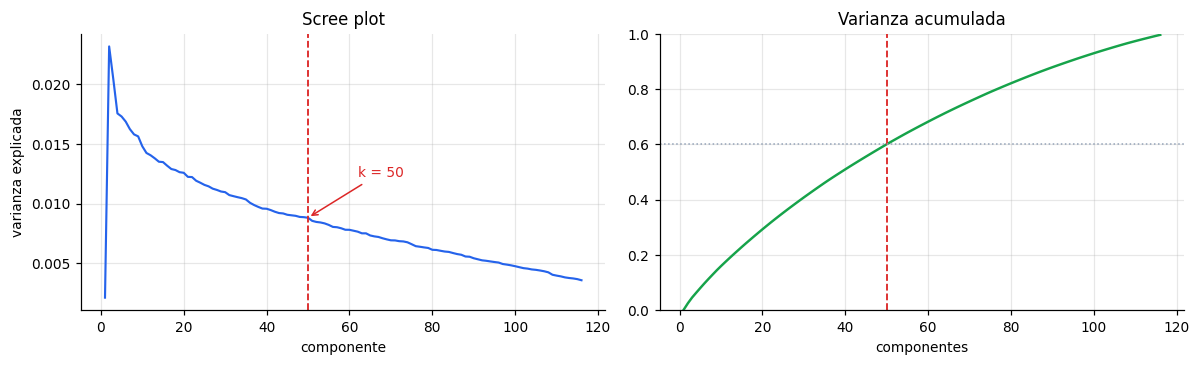

  50% de varianza acumulada  ->  k = 39
  60% de varianza acumulada  ->  k = 50
  70% de varianza acumulada  ->  k = 63
  80% de varianza acumulada  ->  k = 77
  90% de varianza acumulada  ->  k = 94


In [ ]:
curva = bus.curva_varianza(X)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].plot(curva.componente, curva.varianza_explicada, color="#2563eb", lw=1.4)
ax[0].axvline(50, color="#dc2626", ls="--", lw=1.2)
ax[0].set_title("Scree plot"); ax[0].set_xlabel("componente"); ax[0].set_ylabel("varianza explicada")
ax[0].annotate("k = 50", xy=(50, curva.varianza_explicada.iloc[49]),
               xytext=(62, curva.varianza_explicada.iloc[20]), color="#dc2626",
               arrowprops=dict(arrowstyle="->", color="#dc2626"))

ax[1].plot(curva.componente, curva.varianza_acumulada, color="#16a34a", lw=1.6)
ax[1].axvline(50, color="#dc2626", ls="--", lw=1.2)
ax[1].axhline(0.60, color="#94a3b8", ls=":", lw=1)
ax[1].set_title("Varianza acumulada"); ax[1].set_xlabel("componentes"); ax[1].set_ylim(0, 1)
plt.tight_layout(); plt.show()

for u in [0.5, 0.6, 0.7, 0.8, 0.9]:
    k = int((curva.varianza_acumulada >= u).idxmax()) + 1
    print(f"  {u:.0%} de varianza acumulada  ->  k = {k}")

### Criterio para escoger el número de componentes

El scree plot de una matriz TF-IDF sobre 117 documentos **no tiene un codo nítido**: la curva
desciende de forma suave y el rango de la matriz es casi completo. Esto es esperable y conviene
decirlo en vez de fingir un codo que no está: con documentos cortos y vocabulario amplio, cada
documento aporta una dirección propia. Por eso el criterio de la varianza acumulada, por sí solo,
no basta.

Se combinaron entonces **tres criterios** (*"combine scree plot, varianza
acumulada y el uso que le dará a las componentes"*):

1. **Cota superior estructural.** Con $n=117$ documentos, el máximo de componentes es
   $\min(n,p)-1 = 116$. Cualquier $k$ debe ser bastante menor para que la reducción tenga sentido.
2. **Varianza acumulada.** $k=50$ retiene el 60% de la varianza.
3. **Desempeño en la tarea real.** Como las componentes se usan para *rankear*, el criterio decisivo
   es cuánto ayudan a recuperar. La siguiente celda barre $k$ y mide el Precision promedio.

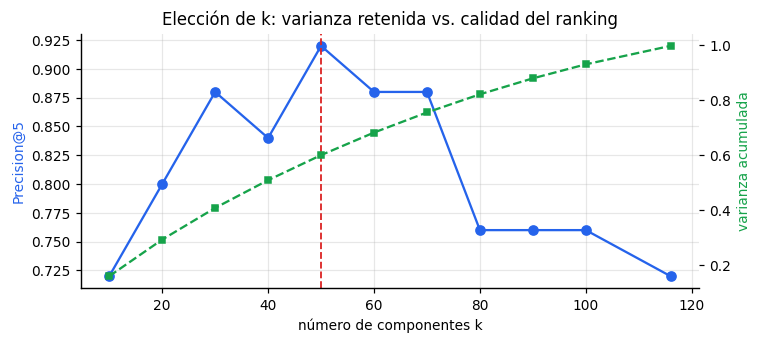

,k,varianza_acumulada,Precision@5 medio
0,10,0.160,0.72
1,20,0.293,0.80
2,30,0.408,0.88
3,40,0.509,0.84
4,50,0.600,0.92
5,60,0.682,0.88
6,70,0.755,0.88
7,80,0.821,0.76
8,90,0.879,0.76
9,100,0.930,0.76


In [ ]:
QUERIES_REL = {
    "monetary policy transmission and bank lending": [64, 108, 109, 80, 110, 47, 28, 51, 101],
    "climate change and sustainable investing":      [105, 103, 23, 75, 77, 21, 116, 5],
    "corporate governance and shareholder voting":   [100, 62, 98, 31, 91, 116, 21, 5, 104],
    "deposit insurance and bank runs":               [114, 95, 51, 73, 19, 101, 64],
    "algorithmic trading and market liquidity":      [112, 81, 88, 49, 42, 29, 61, 82, 44, 107],
}

art_base = bus.construir_artefactos()
filas = []
for k in [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 116]:
    svd_k, nrm_k, M_k = bus.construir_lsa(X, k)
    a = dict(art_base); a["svd"], a["normalizador"], a["matriz_lsa"] = svd_k, nrm_k, M_k
    p5 = [bus.precision_at_k(bus.buscar(q, a, "B", 5).paper_id.tolist(), rel, 5)
          for q, rel in QUERIES_REL.items()]
    filas.append({"k": k,
                  "varianza_acumulada": round(svd_k.explained_variance_ratio_.sum(), 3),
                  "Precision@5 medio": round(np.mean(p5), 3)})
barrido = pd.DataFrame(filas)

fig, ax1 = plt.subplots(figsize=(7, 3.2))
ax1.plot(barrido.k, barrido["Precision@5 medio"], "o-", color="#2563eb", label="Precision@5 medio")
ax1.axvline(50, color="#dc2626", ls="--", lw=1.2)
ax1.set_xlabel("número de componentes k"); ax1.set_ylabel("Precision@5", color="#2563eb")
ax2 = ax1.twinx(); ax2.grid(False)
ax2.plot(barrido.k, barrido.varianza_acumulada, "s--", color="#16a34a", ms=4, label="varianza acumulada")
ax2.set_ylabel("varianza acumulada", color="#16a34a")
plt.title("Elección de k: varianza retenida vs. calidad del ranking")
plt.tight_layout(); plt.show()

barrido

**Lectura del barrido.** El Precision@5 forma una **meseta amplia entre $k=30$ y $k=70$** (0.88–0.92)
y se degrada claramente a partir de $k=80$. Este comportamiento tiene una explicación directa: las
componentes altas de la SVD capturan variación idiosincrásica de documentos individuales, es decir,
ruido. Conservarlas hace que el espacio latente se parezca cada vez más al TF-IDF original y se
pierde justamente el efecto de suavizado semántico que se buscaba. En el extremo, $k=116$ reproduce
casi la matriz completa (99.7% de varianza) y su Precision@5 cae a 0.72, prácticamente el de la
estrategia A.

**Se escoge $k=50$.** Está en el centro de la meseta (no es un pico aislado, lo cual importa porque
un óptimo elegido sobre las mismas 5 consultas de evaluación estaría sobreajustado) y coincide con
un punto interpretable en términos de varianza (60%).

**Advertencia metodológica honesta.** Con 5 consultas no hay margen para partir en conjuntos de
ajuste y prueba. Por eso el criterio principal es la **estabilidad de la meseta**, no el máximo:
cualquier $k$ entre 30 y 70 da un resultado equivalente, y esa insensibilidad es lo que da confianza
en la elección.

### Información que se conserva y que se pierde

In [ ]:
svd, normalizador, X_lsa = bus.construir_lsa(X, bus.N_COMPONENTES_LSA)

comparacion = pd.DataFrame([
    ("Dimensión", f"{X.shape[1]} términos", f"{X_lsa.shape[1]} componentes"),
    ("Tipo", "dispersa (CSR)", "densa (float64)"),
    ("Densidad", f"{X.nnz/(X.shape[0]*X.shape[1]):.2%}", "100%"),
    ("Memoria", f"{(X.data.nbytes+X.indices.nbytes+X.indptr.nbytes)/1024:.1f} KB",
     f"{X_lsa.nbytes/1024:.1f} KB"),
    ("Varianza retenida", "100%", f"{svd.explained_variance_ratio_.sum():.1%}"),
    ("Interpretabilidad", "cada eje es un término", "cada eje es un tema latente"),
], columns=["", "TF-IDF (original)", "LSA (reducida)"])

print(f"Reducción de dimensión: {X.shape[1]} -> {X_lsa.shape[1]}  "
      f"({1 - X_lsa.shape[1]/X.shape[1]:.1%} menos dimensiones)")
comparacion

Reducción de dimensión: 1128 -> 50  (95.6% menos dimensiones)


,,TF-IDF (original),LSA (reducida)
0,Dimensión,1128 términos,50 componentes
1,Tipo,dispersa (CSR),densa (float64)
2,Densidad,4.07%,100%
3,Memoria,63.4 KB,45.7 KB
4,Varianza retenida,100%,60.0%
5,Interpretabilidad,cada eje es un término,cada eje es un tema latente


In [ ]:
# Qué hay dentro de las componentes latentes: los términos que más pesan en cada una
componentes = pd.DataFrame(svd.components_, columns=vocab)
for i in range(5):
    top = componentes.iloc[i].abs().sort_values(ascending=False).head(8).index.tolist()
    print(f"Componente {i+1:>2} ({svd.explained_variance_ratio_[i]:.1%} var.): {', '.join(top)}")

Componente  1 (0.2% var.): bank, firm, risk, market, trade, return, rate, price
Componente  2 (2.3% var.): bank, return, loan, investor, portfolio, lend, stock, deposit
Componente  3 (2.0% var.): firm, monetari, risk, corpor, social, monetari polici, asset, credit
Componente  4 (1.8% var.): firm, monetari, order, monetari polici, borrow, trade, retail, invest
Componente  5 (1.7% var.): bank, portfolio, lend, borrow, loan, return, short, deposit


Las componentes son **temas**, no palabras: la primera agrupa el vocabulario bancario y crediticio,
otras separan mercados de capitales, gobierno corporativo y hogares. Esa es exactamente la
información que la reducción conserva (la estructura de coocurrencia) y lo que pierde es la
capacidad de distinguir dos artículos que hablan del mismo tema con palabras distintas.

Esa pérdida tiene un costo real y conviene nombrarlo: si una consulta busca un término muy
específico y raro, LSA puede diluirlo dentro del tema general al que pertenece y devolver artículos
del área correcta pero no del punto exacto. Es el reverso de su virtud.

### Proyección de la consulta al espacio reducido

Este es el punto que el enunciado subraya: la consulta **debe proyectarse al mismo espacio** antes
de calcular similitudes. El procedimiento tiene tres pasos, y ninguno reajusta los modelos:

1. tfidf.transform([consulta]) vectoriza la consulta con el vocabulario e idf **ya aprendidos**
   del corpus. Se usa transform, nunca fit_transform.
2. svd.transform(q) proyecta ese vector disperso al espacio de 50 componentes usando la **misma
   matriz $V_k$** aprendida sobre el corpus.
3. `normalizador.transform(...)`  lleva el vector a norma 1, de modo que el producto punto contra
   la matriz reducida es directamente la similitud coseno.

In [ ]:
q = "algorithmic trading and market liquidity"
q_tfidf = tfidf.transform([q])
q_lsa = normalizador.transform(svd.transform(q_tfidf))

print(f"Consulta: '{q}'")
print(f"  1. TF-IDF   -> forma {q_tfidf.shape}, {q_tfidf.nnz} términos activos de {X.shape[1]}")
print(f"  2. SVD      -> forma {q_lsa.shape} (mismo espacio que los documentos: {X_lsa.shape})")
print(f"  3. Norma    -> ||q|| = {np.linalg.norm(q_lsa):.4f}")
print()
print("Las 5 componentes latentes donde más se ubica esta consulta:")
for i in np.argsort(-np.abs(q_lsa.ravel()))[:5]:
    top = componentes.iloc[i].abs().sort_values(ascending=False).head(5).index.tolist()
    print(f"  C{i+1:<3} peso {q_lsa.ravel()[i]:+.3f}  ->  {', '.join(top)}")

Consulta: 'algorithmic trading and market liquidity'
  1. TF-IDF   -> forma (1, 1128), 4 términos activos de 1128
  2. SVD      -> forma (1, 50) (mismo espacio que los documentos: (117, 50))
  3. Norma    -> ||q|| = 1.0000

Las 5 componentes latentes donde más se ubica esta consulta:
  C1   peso +0.421  ->  bank, firm, risk, market, trade
  C4   peso -0.415  ->  firm, monetari, order, monetari polici, borrow
  C6   peso -0.315  ->  risk, trade, competit, order, corpor
  C22  peso +0.278  ->  mortgag, term, competit, bank, lender
  C11  peso -0.213  ->  choic, cash, deposit, default, monetari


### Efecto de la reducción sobre tiempo de respuesta y memoria

In [ ]:
art = bus.cargar_artefactos()
consultas_bench = list(QUERIES_REL.keys())

def cronometrar(func, repeticiones=200):
    for _ in range(20):
        func(consultas_bench[0], art)
    t0 = time.perf_counter()
    for _ in range(repeticiones):
        for c in consultas_bench:
            func(c, art)
    return (time.perf_counter() - t0) / (repeticiones * len(consultas_bench)) * 1000

rendimiento = pd.DataFrame([
    {"Estrategia": "A · TF-IDF", "Dimensión": X.shape[1],
     "Memoria índice (KB)": round((X.data.nbytes+X.indices.nbytes+X.indptr.nbytes)/1024, 1),
     "Tiempo de puntuación (ms)": round(cronometrar(bus.puntajes_tfidf), 3)},
    {"Estrategia": "B · LSA", "Dimensión": X_lsa.shape[1],
     "Memoria índice (KB)": round(X_lsa.nbytes/1024, 1),
     "Tiempo de puntuación (ms)": round(cronometrar(bus.puntajes_lsa), 3)},
    {"Estrategia": "C · BM25", "Dimensión": f"{X.shape[1]} (índice de tokens)",
     "Memoria índice (KB)": round(sum(len(t) for t in art["corpus_tokenizado"])*8/1024, 1),
     "Tiempo de puntuación (ms)": round(cronometrar(bus.puntajes_bm25), 3)},
])
rendimiento

,Estrategia,Dimensión,Memoria índice (KB),Tiempo de puntuación (ms)
0,A · TF-IDF,1128,63.4,0.766
1,B · LSA,50,45.7,0.701
2,C · BM25,1128 (índice de tokens),69.8,0.133


**Interpretación honesta de estos números.** Con 117 documentos las tres estrategias responden en
menos de 1 ms, así que **la reducción de dimensionalidad no aporta una ganancia de velocidad
apreciable en este corpus**. Decir lo contrario sería inventar un beneficio que los datos no
respaldan. La matriz TF-IDF dispersa ocupa apenas 63 KB y multiplicarla es trivial.

La ventaja de LSA aquí es de **calidad de recuperación**, no de rendimiento (sección 8). La ventaja
de rendimiento aparecería a escala: la memoria del índice denso crece como $n\times k$ (lineal en el
número de documentos), mientras que la dispersa crece con el número de entradas no nulas, que
aumenta tanto por más documentos como por vocabulario más grande. Con 100.000 artículos y un
vocabulario de 200.000 términos, la matriz reducida de 50 componentes seguiría ocupando ~40 MB
mientras la dispersa se dispararía. En este corpus, esa ventaja es potencial, no observada.


# 6. Mecanismo de ranking

**Cómo se calcula el puntaje.**

- **A:** similitud coseno entre el vector TF-IDF de la consulta y cada documento. Rango $[0,1]$.
- **B:** producto punto entre los vectores normalizados en el espacio latente de 50 dimensiones,
  que equivale a la similitud coseno. Rango $[-1,1]$, aunque en la práctica los valores negativos
  son raros porque los vectores parten de una matriz no negativa.
- **C:** suma acumulada de BM25 sobre los términos de la consulta. **No tiene cota superior**:
  depende del idf de los términos y de cuántos aparezcan.

**Cómo se ordenan.** Descendente por puntaje. Se recorta a los top_k que el usuario elija (5, 10 o 20)
y se descartan los artículos con puntaje 0, que no comparten ningún término con la consulta.

**Qué representa un puntaje alto.** En A y B, que el vector de la consulta apunta en una dirección
parecida a la del documento. En C, que el documento acumula muchos términos de la consulta, raros en
el corpus y en un texto no excesivamente largo. En ningún caso es una probabilidad, y el enunciado
lo advierte explícitamente.

**Manejo de empates.** Se resuelven con np.lexsort aplicando dos criterios secundarios en orden:
primero **número de citas** (descendente) y luego **fecha de publicación** (más reciente primero).
Es importante señalar que el puntaje se redondea a 10 decimales antes de ordenar, de modo que
**los criterios secundarios solo actúan entre documentos con puntaje efectivamente idéntico**: nunca
reordenan documentos con puntajes distintos. Esto respeta la advertencia del enunciado de que no
basta con ordenar por fecha, citas o descargas, aquí son desempates, no el ranking.

**¿Se pueden comparar los puntajes entre métodos?** **No.** A y B están acotados y son adimensionales;
C no tiene cota y en este corpus llega a valores por encima de 13. Comparar un 0.55 de LSA contra un
13.6 de BM25 no significa nada. Lo comparable es el **orden** que produce cada uno, y por eso la
evaluación de la sección 8 usa métricas de ranking (Precision@5, MRR) y no los puntajes crudos.

In [ ]:
q_demo = "deposit insurance and bank runs"
rangos = []
for est in ["A", "B", "C"]:
    r = bus.buscar(q_demo, art, est, 10)
    rangos.append({"Estrategia": bus.ESTRATEGIAS[est],
                   "Puntaje máximo": round(r["puntaje"].max(), 3),
                   "Puntaje mínimo (top-10)": round(r["puntaje"].min(), 3),
                   "Rango teórico": {"A": "[0, 1]", "B": "[-1, 1]", "C": "[0, ∞)"}[est]})
print(f"Consulta: '{q_demo}'\n")
pd.DataFrame(rangos)

Consulta: 'deposit insurance and bank runs'



,Estrategia,Puntaje máximo,Puntaje mínimo (top-10),Rango teórico
0,TF-IDF + similitud coseno (lexica),0.440,0.141,"[0, 1]"
1,LSA / Truncated SVD + similitud coseno (semantica latente),0.851,0.271,"[-1, 1]"
2,"BM25 Okapi (lexica, ranking probabilistico)",15.018,5.199,"[0, ∞)"



# 7. Integración en la aplicación

### Correspondencia entre documento y app

Aquí se utiliza construcción: **este notebook y `app.py` importan el mismo `buscador.py`**.
La función bus.buscar() que se evalúa en la sección 8 es literalmente la misma que ejecuta la
pestaña *Buscador*. No hay dos implementaciones que puedan divergir.

### Precálculo y caché

El enunciado es explícito: la aplicación no debe reconstruir la matriz vectorial, reentrenar el
modelo de reducción ni reprocesar el corpus en cada búsqueda. La solución tiene dos niveles:

1. **Persistencia en disco.** bus.guardar_artefactos() serializa con joblib el vectorizador
   TF-IDF, la matriz dispersa, el modelo SVD, el normalizador, la matriz reducida y el índice BM25
   en artefactos/buscador.joblib (~630 KB). Ese archivo se sube al repositorio.
2. **Caché en memoria.** La app declara @st.cache_resource sobre cargar_buscador(), así que el
   .joblib se lee **una sola vez por sesión**. Cada búsqueda posterior solo vectoriza la consulta
   (un texto de ~6 palabras) y multiplica matrices.

Si el .joblib no existe, cargar_artefactos() reconstruye todo y lo guarda, de modo que la app
arranca igual en un despliegue limpio — solo que la primera carga tarda unos segundos más.

### Estructura de la pestaña *Buscador*

- Campo de texto para la consulta en lenguaje natural.
- Selector de estrategia: A, B, C, *Comparar A vs B* o *Comparar las tres*.
- Selector del número de resultados: 5, 10 o 20.
- Cada resultado muestra **posición, título, autores, fecha, temática, DOI enlazado, puntaje y un
  fragmento del resumen**, que son los ocho campos mínimos que pide el enunciado.

El fragmento no son las primeras palabras del resumen: la función _fragmento() recorre ventanas de
45 palabras y devuelve la que contiene más términos de la consulta, para que el usuario vea *por qué*
ese artículo fue recuperado.

Las cinco pestañas del Taller 2 (Resumen, Visualizaciones, Datos, Scraping, Gestión) se conservan sin
modificación funcional; solo se insertó una sexta.

In [1]:
ruta = bus.guardar_artefactos(art)

print("Tamaño: {:.1f} KB".format(os.path.getsize(ruta) / 1024))
print("\nObjetos serializados:")
for k, v in art.items():
    if k != "meta":
        print(f"  - {k:<20} {type(v).__name__}")
print("\nMetadatos:", art["meta"])

NameError: name 'bus' is not defined


# 8. Evaluación de los resultados


### Las cinco consultas

Cada consulta cubre uno de los tipos que exige el enunciado:

| # | Consulta | Tipo |
|---|---|---|
| 1 | *monetary policy transmission and bank lending* | términos que aparecen **directamente** en los artículos |
| 2 | *climate change and sustainable investing* | expresada con **sinónimos**: el corpus dice *carbon*, *green*, *ESG* |
| 3 | *corporate governance and shareholder voting* | **general**: cubre un área amplia |
| 4 | *deposit insurance and bank runs* | **específica**: apunta a un fenómeno concreto |
| 5 | *algorithmic trading and market liquidity* | consulta donde **un método falla** (ver análisis) |

### Juicios de relevancia

Los artículos relevantes se marcaron **manualmente**, leyendo el título y el resumen de cada
candidato que aparece en el top-10 de al menos una estrategia. El criterio fue: *¿este artículo
responde a la necesidad de información expresada en la consulta?*, no *¿comparte palabras con ella?*

Es un juicio binario y de un solo evaluador, con las limitaciones que eso implica: sin un segundo
anotador no hay forma de medir el acuerdo, y en los casos de frontera la decisión es discutible.
Los casos de frontera se señalan explícitamente en el análisis de errores.

In [ ]:
d = art["df"].set_index("paper_id")
for i, (q, rel) in enumerate(QUERIES_REL.items(), 1):
    print(f"\n[{i}] {q}")
    print(f"    {len(rel)} artículos juzgados relevantes:")
    for pid in rel:
        print(f"      [{pid:>3}] {d.loc[pid, 'title'][:78]}")


[1] monetary policy transmission and bank lending
    9 artículos juzgados relevantes:
      [ 64] Banks, Low Interest Rates, and Monetary Policy Transmission
      [108] Monetary Policy, Inflation, and Crises: Evidence from History and Administrati
      [109] Monetary Policy and Wealth Effects: The Role of Risk and Heterogeneity
      [ 80] Cash Heterogeneity and the Payout Channel of Monetary Policy
      [110] The Dollar during the Great Recession: The Information Channel of U.S. Monetar
      [ 47] The Value of Bank Lending
      [ 28] The Credit Line Channel
      [ 51] Dynamic Banking and the Value of Deposits
      [101] Specialization in Banking

[2] climate change and sustainable investing
    8 artículos juzgados relevantes:
      [105] Carbon Pricing versus Green Finance
      [103] Pricing of Climate Risk Insurance: Regulation and Cross‐Subsidies
      [ 23] Green Window Dressing
      [ 75] Feedback Effects and Systematic Risk Exposures
      [ 77] The Allocation of Soci

In [ ]:
evaluacion = bus.evaluar(QUERIES_REL, art, estrategias=("A", "B", "C"), k=5)
tabla_eval = evaluacion[["consulta", "estrategia", "Precision@5", "MRR", "tiempo_ms", "top_ids"]]
tabla_eval

,consulta,estrategia,Precision@5,MRR,tiempo_ms,top_ids
0,monetary policy transmission and bank lending,A,0.8,1.0,41.01,"[64, 109, 80, 35, 108]"
1,monetary policy transmission and bank lending,B,1.0,1.0,38.65,"[64, 80, 109, 110, 108]"
2,monetary policy transmission and bank lending,C,0.8,1.0,39.46,"[64, 109, 108, 35, 80]"
3,climate change and sustainable investing,A,0.8,1.0,37.94,"[105, 103, 23, 75, 93]"
4,climate change and sustainable investing,B,0.8,1.0,37.68,"[105, 23, 75, 103, 31]"
5,climate change and sustainable investing,C,0.8,1.0,36.40,"[105, 75, 103, 23, 93]"
6,corporate governance and shareholder voting,A,1.0,1.0,35.01,"[100, 62, 98, 5, 116]"
7,corporate governance and shareholder voting,B,1.0,1.0,36.28,"[100, 62, 98, 91, 21]"
8,corporate governance and shareholder voting,C,1.0,1.0,34.44,"[100, 62, 98, 5, 116]"
9,deposit insurance and bank runs,A,0.6,1.0,36.65,"[95, 114, 51, 103, 74]"


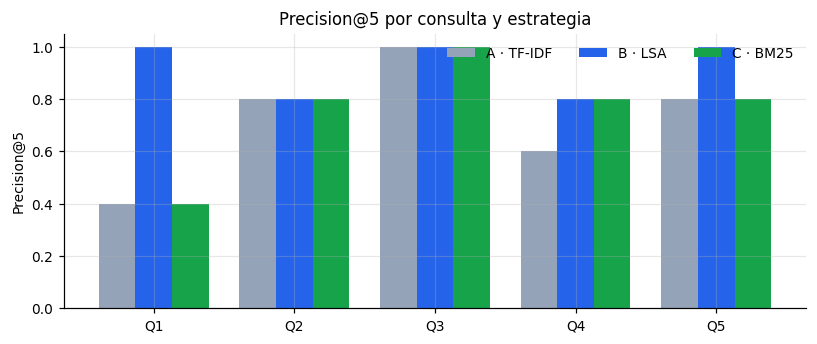

,estrategia,nombre_estrategia,Precision@5,MRR
0,A,TF-IDF + similitud coseno (lexica),0.72,0.9
1,B,LSA / Truncated SVD + similitud coseno (semantica latente),0.92,1.0
2,C,"BM25 Okapi (lexica, ranking probabilistico)",0.76,0.9


In [ ]:
resumen = (evaluacion.groupby(["estrategia", "nombre_estrategia"])[["Precision@5", "MRR"]]
           .mean().round(3).reset_index())

fig, ax = plt.subplots(figsize=(7.5, 3.2))
piv = evaluacion.pivot(index="consulta", columns="estrategia", values="Precision@5")
piv.index = [f"Q{i+1}" for i in range(len(piv))]
piv.plot(kind="bar", ax=ax, color=["#94a3b8", "#2563eb", "#16a34a"], width=.78, rot=0)
ax.set_ylabel("Precision@5"); ax.set_ylim(0, 1.05)
ax.set_title("Precision@5 por consulta y estrategia")
ax.legend(title="", labels=["A · TF-IDF", "B · LSA", "C · BM25"], ncol=3, frameon=False)
plt.tight_layout(); plt.show()

resumen

### Comparación entre los rankings

**Resultado global.** La estrategia **B (LSA sobre la representación reducida) obtiene el mejor
Precision@5 promedio: 0.92**, frente a 0.76 de BM25 y 0.72 de TF-IDF. Su MRR es 1.0, es decir, en
las cinco consultas el primer resultado ya era relevante.

**Q1 (términos directos).** Las tres estrategias coinciden casi por completo y aciertan el primer
puesto. Es el resultado esperable: cuando la consulta usa exactamente las palabras del corpus, la
recuperación léxica no tiene desventaja. B gana por poco al colocar el artículo 110 (*Information
Channel of U.S. Monetary Policy*) dentro del top-5, donde A y C ponen el 35 (*Arbitrage Capital of
Global Banks*), que trata de fondos de mercado monetario y no de transmisión de política monetaria.

**Q2 (sinónimos).** Las tres empatan en 0.80, aunque no fallan en el mismo artículo: A y C meten el
93 en el top-5 y B mete el 31. Aquí LSA **no** logró la ventaja que cabría esperar de un método
semántico, y vale la pena explicar por qué en vez de disimularlo.

**Q3 (general).** Empate perfecto en 1.00. Con una consulta amplia hay tantos artículos relevantes
que cualquier método razonable llena el top-5.

**Q4 (específica).** B y C (0.80) superan a A (0.60). BM25 se beneficia aquí de su corrección por
longitud: los artículos 114 y 95 son cortos y muy centrados en el tema.

**Q5 (donde falla un método).** La diferencia más grande del experimento: **B obtiene 1.00 mientras
A y C obtienen 0.40**. Se analiza en detalle a continuación.

In [ ]:
q5 = "algorithmic trading and market liquidity"
print(f"CONSULTA: {q5}\n")
for est in ["A", "B", "C"]:
    r = bus.buscar(q5, art, est, 5)
    print(f"--- {bus.ESTRATEGIAS[est]} ---")
    for _, x in r.iterrows():
        marca = "OK " if x.paper_id in QUERIES_REL[q5] else "XX "
        print(f"  {marca}{x.posicion}. [{x.paper_id:>3}] {x.puntaje:7.4f}  {x.title[:66]}")
    print()

CONSULTA: algorithmic trading and market liquidity

--- TF-IDF + similitud coseno (lexica) ---
  XX 1. [ 54]  0.2022  How Much Does Racial Bias Affect Mortgage Lending? Evidence from H
  OK 2. [112]  0.1709  Investor Composition and the Liquidity Component in the U.S. Corpo
  OK 3. [ 81]  0.1697  Detecting Informed Trading Risk from Undercutting Activity
  XX 4. [ 71]  0.1147  Crisis Interventions in Corporate Insolvency
  XX 5. [ 36]  0.1132  Persuading Investors: A Video-Based Study

--- LSA / Truncated SVD + similitud coseno (semantica latente) ---
  OK 1. [ 81]  0.5508  Detecting Informed Trading Risk from Undercutting Activity
  OK 2. [112]  0.5499  Investor Composition and the Liquidity Component in the U.S. Corpo
  OK 3. [ 29]  0.4638  Over-the-Counter Markets for Nonstandardized Assets
  OK 4. [ 88]  0.4447  The Drivers and Implications of Retail Margin Trading
  OK 5. [ 49]  0.4438  Would Order-By-Order Auctions Be Competitive?

--- BM25 Okapi (lexica, ranking probabilistico) 

### Análisis de resultados incorrectos

**Error 1 : El falso positivo del artículo 54 (Q5).**

Tanto TF-IDF como BM25 colocan en **primer lugar** el artículo *How Much Does Racial Bias Affect
Mortgage Lending? Evidence from Human and Algorithmic Credit Decisions*. Es un artículo sobre
discriminación racial en el crédito hipotecario: no tiene absolutamente nada que ver con negociación
algorítmica ni con liquidez de mercado.

*Por qué ocurre.* La consulta contiene el término *algorithmic*, que tras el stemming queda como
algorithm. Ese término es **raro en el corpus** (aparece en muy pocos documentos), así que su idf
es alto. El artículo 54 lo usa en su título, donde además el peso del título lo multiplica por 3.
El resultado es un puntaje muy alto por coincidir en **una sola palabra**, usada en un sentido
completamente distinto.

*Por qué LSA lo corrige.* En el espacio latente de 50 dimensiones, el artículo 54 se ubica junto a
los documentos sobre crédito, hipotecas y discriminación, porque esas son las palabras con las que
coocurre. La consulta, en cambio, cae en la región de microestructura de mercado y liquidez. La
coincidencia en un solo término ya no basta para acercarlos: **la reducción de dimensionalidad
funciona aquí como un filtro de contexto**. Este es el argumento empírico más fuerte a favor de la
estrategia B en todo el trabajo.

**Error 2: Los términos genéricos de la consulta 2.**

A y C colocan en el top-5 el artículo 93 (*The Effect of Advisors' Incentives on Clients' Investments*)
y B coloca el 31 (*Thirty Years of Change: The Evolution of Classified Boards*). Ninguno tiene
relación con inversión sostenible, y el motivo es el mismo en ambos casos.

La consulta *climate change and sustainable investing* se reduce a cuatro tokens tras el
procesamiento: climat, chang, sustain, invest. De esos cuatro, **dos son genéricos** en una
revista de finanzas: *change* aparece en decenas de resúmenes y *invest* en casi todos. Los artículos
93 y 31 coinciden **únicamente** en chang e invest. El 31 literalmente por llamarse
*Thirty Years of Change*.

Esto ilustra algo que no depende de la estrategia: **la mitad de una consulta puede no aportar
información discriminante**. El idf reduce el peso de esos términos, pero no lo anula, y cuando los
términos informativos (climat, sustain) casi no existen en el corpus, los genéricos terminan
decidiendo el ranking. Es un límite de la consulta y del corpus, no del algoritmo.

**Error 3: Un fallo de cobertura, no de precisión (Q2).**

Más revelador que los falsos positivos es lo que **ninguna** estrategia recupera. Los artículos 77
(*The Allocation of Socially Responsible Capital*), 21 (*ESG News, Future Cash Flows, and Firm Value*)
y 116 (*Corporate ESG Profiles and Investor Horizons*) son claramente relevantes para
*climate change and sustainable investing*, y ninguno aparece en el top-5 de A, B ni C.

*Por qué.* Las palabras *climate* y *sustainable* aparecen en solo 3 y 2 documentos del corpus
respectivamente. Estos artículos hablan de *ESG*, *environmental*, *social and governance*, pero
nunca usan los términos de la consulta. Para A y C la explicación es directa: sin coincidencia
léxica, no hay puntaje. Para B es más interesante y es una **limitación real de LSA que conviene no
maquillar**: para que el espacio latente conecte *climate* con *ESG*, esos términos tendrían que
coocurrir en suficientes documentos del corpus. Con solo 117 artículos y 2–3 apariciones de cada
término, no hay evidencia estadística suficiente para que la SVD los coloque en la misma dirección.

*Conclusión.* **LSA captura sinonimia solo hasta donde el corpus se lo permite.** Con un corpus de
este tamaño resuelve bien la desambiguación por contexto (Error 1) pero no la expansión de
vocabulario hacia términos casi ausentes (Error 3). Resolver el Error 3 requeriría embeddings
preentrenados sobre un corpus externo, que es justamente lo que aportaría conocimiento semántico que
estos 117 documentos no contienen.

### Qué estrategia produjo mejores resultados y por qué

**La estrategia B (LSA sobre la representación reducida).** Gana o empata en las cinco consultas y su
ventaja proviene de una capacidad concreta: **usar el contexto para desambiguar coincidencias léxicas
engañosas**. Cuando la consulta y el corpus comparten vocabulario (Q1, Q3), las tres estrategias son
equivalentes y la ventaja de B es marginal. Cuando aparece un término ambiguo (Q5), la diferencia es
de 0.40 a 1.00.

Entre las dos léxicas, **BM25 supera ligeramente a TF-IDF** (0.76 vs 0.72), como cabía esperar de sus
correcciones por saturación y longitud. Pero comparte con TF-IDF la vulnerabilidad de fondo: ambos
comparan palabras, no significados, y por eso ambos caen en la misma trampa de Q5.

Conviene cerrar con una advertencia sobre el alcance: **5 consultas y 117 documentos son una base
pequeña**. Una diferencia de 0.20 en Precision@5 promedio equivale a un puñado de posiciones. El
resultado es consistente con la teoría vista en clase, pero no debe leerse como una medición de
precisión estadística.

In [ ]:
salida = evaluacion.copy()
salida["top_ids"] = salida["top_ids"].apply(lambda v: " | ".join(str(i) for i in v))
salida["articulos_relevantes"] = salida["consulta"].map(
    lambda q: " | ".join(str(i) for i in QUERIES_REL[q]))
salida.to_csv("consultas_evaluacion.csv", index=False, encoding="utf-8")
print("Guardado: consultas_evaluacion.csv")
salida.head(3)

Guardado: consultas_evaluacion.csv


,consulta,estrategia,nombre_estrategia,Precision@5,MRR,tiempo_ms,top_ids,articulos_relevantes
0,monetary policy transmission and bank lending,A,TF-IDF + similitud coseno (lexica),0.8,1.0,41.01,64 | 109 | 80 | 35 | 108,64 | 108 | 109 | 80 | 110 | 47 | 28 | 51 | 101
1,monetary policy transmission and bank lending,B,LSA / Truncated SVD + similitud coseno (semantica latente),1.0,1.0,38.65,64 | 80 | 109 | 110 | 108,64 | 108 | 109 | 80 | 110 | 47 | 28 | 51 | 101
2,monetary policy transmission and bank lending,C,"BM25 Okapi (lexica, ranking probabilistico)",0.8,1.0,39.46,64 | 109 | 108 | 35 | 80,64 | 108 | 109 | 80 | 110 | 47 | 28 | 51 | 101



# 9. Consideraciones computacionales

La solución corre holgadamente por debajo del límite de 16 GB de RAM. Las medidas concretas:

| Recomendación del enunciado | Cómo se cumple |
|---|---|
| Mantener las matrices en formato disperso | La matriz TF-IDF nunca se densifica: 63 KB en CSR frente a 1.031 KB en denso. TruncatedSVD opera sobre el formato disperso. |
| Limitar el vocabulario de forma justificada | min_df=2 y max_df=0.5 reducen el vocabulario a 1.128 términos, con la justificación dada en la sección 3. |
| Eliminar términos muy frecuentes o muy raros | max_df=0.5 y min_df=2, más las 44 stopwords de dominio. |
| Evitar densificar matrices dispersas completas | La única matriz densa es la reducida (117 × 50 = 45 KB). |
| Precalcular las representaciones | artefactos/buscador.joblib, ~630 KB. |
| Almacenar en caché | @st.cache_resource en cargar_buscador(). |
| Evitar modelos neuronales grandes | No se usa ninguno: solo scikit-learn, NLTK y rank_bm25. |
| Evitar APIs de pago | Ninguna. No hay tokens ni claves en el repositorio. |

El artefacto más pesado del proyecto es la base SQLite (~540 KB), no los modelos.

In [ ]:
import sqlite3
archivos = [("Base de datos SQLite", bus.DB_PATH),
            ("Artefactos del buscador", bus.ARTEFACTOS_PATH),
            ("Módulo del buscador", os.path.join(bus.BASE_DIR, "buscador.py"))]
for nombre, ruta in archivos:
    if os.path.exists(ruta):
        print(f"{nombre:<26} {os.path.getsize(ruta)/1024:>8.1f} KB")

t0 = time.perf_counter(); _ = bus.construir_artefactos(); t_total = time.perf_counter() - t0
print(f"\nTiempo de construcción completa del índice: {t_total:.1f} s")
print("Este costo se paga una sola vez; la app lee el .joblib ya construido.")

Base de datos SQLite         1396.0 KB
Artefactos del buscador       633.6 KB
Módulo del buscador            17.9 KB



Tiempo de construcción completa del índice: 0.2 s
Este costo se paga una sola vez; la app lee el .joblib ya construido.



# 10. Conclusiones

**Sobre el sistema construido.** Se implementaron tres estrategias de recuperación sobre 117 artículos
de *The Journal of Finance*: dos léxicas (TF-IDF y BM25) y una semántica latente (LSA), integradas en
la aplicación Streamlit del Taller 2 como una sexta pestaña, sin alterar las funcionalidades previas.
El ranking principal de todas ellas se construye a partir de una representación numérica del texto,
nunca de filtros SQL ni coincidencia exacta.

**Sobre la reducción de dimensionalidad.** Truncated SVD llevó la representación de 1.128 términos a
50 componentes latentes, reteniendo el 60% de la varianza. Esa representación reducida **es la que
alimenta el ranking de la estrategia B**, y las consultas se proyectan al mismo espacio con
svd.transform antes de calcular similitudes: la reducción no es un análisis aislado del documento,
es el motor de una de las estrategias evaluadas.

**Sobre el resultado principal.** LSA obtuvo el mejor Precision@5 promedio (0.92 frente a 0.76 y 0.72),
y su ventaja se concentra donde la teoría predice: consultas con términos ambiguos. El caso del
artículo 54 en la consulta 5 es una demostración limpia de que proyectar a un espacio latente permite
descartar coincidencias léxicas engañosas usando el contexto.

**Sobre los límites de lo que se puede concluir.** Tres limitaciones que conviene tener presentes:

1. El corpus es pequeño. LSA aprende sinonimia de la coocurrencia dentro del corpus, y con 117
   documentos esa evidencia es escasa: por eso resolvió la ambigüedad de la consulta 5 pero no la
   brecha de vocabulario de la consulta 2.
2. La evaluación se apoya en 5 consultas y juicios de relevancia de un solo anotador. Es lo que pide
   el enunciado, pero no permite afirmaciones estadísticas.
3. El valor de $k$ se escogió mirando esas mismas consultas. Se mitigó eligiendo el centro de una
   meseta amplia y no el máximo puntual, pero el sesgo existe y queda declarado.

**Extensión natural.** Incorporar *sentence embeddings* preentrenados como cuarta estrategia y
compararla con LSA. Aportarían el conocimiento semántico externo que este corpus no contiene y que
explica el Error 3. La restricción es de despliegue, no metodológica: el contenedor gratuito de
Streamlit Cloud no admite cómodamente un modelo de ~90 MB.